# 01 - Data Exploration

## AI Support Copilot with RAG and Ticket Classification

This notebook explores the customer support ticket dataset and prepares a cleaned version for later machine learning, SQL loading, RAG, and dashboard development.

In [399]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Checking to see if file exist in the folder

In [400]:
RAW_DATA_PATH = Path("../data/raw/customer_support_tickets.csv")
PROCESSED_DATA_PATH = Path("../data/processed/cleaned_support_tickets.csv")

RAW_DATA_PATH.exists()

True

Loading dataset

In [401]:
df = pd.read_csv(RAW_DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 8469
Columns: 17


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Checking all Column Names to see which ones to use. 

In [402]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

Clean column names

This converts columns into clean snake_case names. It will allow us to use the column names without any issues. 

In [403]:
def clean_column_name(col):
    return (
        col.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

df.columns = [clean_column_name(col) for col in df.columns]

df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'customer_age',
       'customer_gender', 'product_purchased', 'date_of_purchase',
       'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status',
       'resolution', 'ticket_priority', 'ticket_channel',
       'first_response_time', 'time_to_resolution',
       'customer_satisfaction_rating'],
      dtype='str')

Checking basic dataset information. 

In [404]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ticket_id                     8469 non-null   int64  
 1   customer_name                 8469 non-null   str    
 2   customer_email                8469 non-null   str    
 3   customer_age                  8469 non-null   int64  
 4   customer_gender               8469 non-null   str    
 5   product_purchased             8469 non-null   str    
 6   date_of_purchase              8469 non-null   str    
 7   ticket_type                   8469 non-null   str    
 8   ticket_subject                8469 non-null   str    
 9   ticket_description            8469 non-null   str    
 10  ticket_status                 8469 non-null   str    
 11  resolution                    2769 non-null   str    
 12  ticket_priority               8469 non-null   str    
 13  ticket_channel

Checking missing values

In [405]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values



customer_satisfaction_rating    5700
resolution                      5700
time_to_resolution              5700
first_response_time             2819
ticket_id                          0
customer_name                      0
customer_email                     0
customer_age                       0
customer_gender                    0
ticket_subject                     0
ticket_type                        0
date_of_purchase                   0
product_purchased                  0
ticket_priority                    0
ticket_status                      0
ticket_description                 0
ticket_channel                     0
dtype: int64

In [406]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage

customer_satisfaction_rating    67.304286
resolution                      67.304286
time_to_resolution              67.304286
first_response_time             33.286102
ticket_id                        0.000000
customer_name                    0.000000
customer_email                   0.000000
customer_age                     0.000000
customer_gender                  0.000000
ticket_subject                   0.000000
ticket_type                      0.000000
date_of_purchase                 0.000000
product_purchased                0.000000
ticket_priority                  0.000000
ticket_status                    0.000000
ticket_description               0.000000
ticket_channel                   0.000000
dtype: float64

## Missing Value Diagnosis

Before filling or dropping missing values, we investigate why values are missing.

The goal is to avoid removing records where missing values are logically expected. For example, a resolution field may only be available for closed tickets, while open tickets may not have a final resolution yet.

Missing values summary table
This gives a clean table instead of just a count.

In [407]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2),
    "data_type": df.dtypes
}).sort_values(by="missing_count", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage,data_type
customer_satisfaction_rating,5700,67.30,float64
resolution,5700,67.30,str
time_to_resolution,5700,67.30,str
first_response_time,2819,33.29,str


Show rows with missing values

In [408]:
rows_with_missing = df[df.isnull().any(axis=1)]

print("Rows with at least one missing value:", rows_with_missing.shape[0])
print("Percentage of dataset with at least one missing value:", round(rows_with_missing.shape[0] / df.shape[0] * 100, 2))

rows_with_missing.head(10)

Rows with at least one missing value: 5700
Percentage of dataset with at least one missing value: 67.3


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN
12,13,Tamara Hahn,jensenwilliam@example.net,27,Other,Nintendo Switch Pro Controller,2021-05-26,Technical issue,Hardware issue,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Chat,2023-06-01 19:03:53,NaN,NaN
13,14,Sandra Barnes,gwendolyn51@example.net,65,Other,Nest Thermostat,2020-07-13,Technical issue,Product setup,"I've recently set up my {product_purchased}, b...",Pending Customer Response,NaN,Low,Chat,2023-06-01 20:34:54,NaN,NaN
15,16,Elizabeth Foley,amy41@example.net,18,Other,GoPro Action Camera,2021-06-24,Billing inquiry,Product recommendation,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Social media,2023-06-01 15:09:57,NaN,NaN


Check missingness by ticket status
This is important because fields like resolution, time_to_resolution, or customer_satisfaction_rating may logically depend on whether the ticket is closed.
If resolution is mostly missing for Open or Pending Customer Response tickets, this is logical.
If resolution is missing for many Closed tickets, that is a data quality issue.

In [409]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"\nMissing values in: {col}")
        display(
            df.groupby("ticket_status")[col]
            .apply(lambda x: x.isnull().sum())
            .sort_values(ascending=False)
        )


Missing values in: resolution


ticket_status
Pending Customer Response    2881
Open                         2819
Closed                          0
Name: resolution, dtype: int64


Missing values in: first_response_time


ticket_status
Open                         2819
Closed                          0
Pending Customer Response       0
Name: first_response_time, dtype: int64


Missing values in: time_to_resolution


ticket_status
Pending Customer Response    2881
Open                         2819
Closed                          0
Name: time_to_resolution, dtype: int64


Missing values in: customer_satisfaction_rating


ticket_status
Pending Customer Response    2881
Open                         2819
Closed                          0
Name: customer_satisfaction_rating, dtype: int64

Missingness by ticket type
This helps check whether a field is missing only for specific categories, such as refund, billing, technical issue, etc.

In [410]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"\nMissing values in: {col}")
        display(
            df.groupby("ticket_channel")[col]
            .apply(lambda x: x.isnull().sum())
            .sort_values(ascending=False)
        )


Missing values in: resolution


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: resolution, dtype: int64


Missing values in: first_response_time


ticket_channel
Phone           736
Email           701
Social media    697
Chat            685
Name: first_response_time, dtype: int64


Missing values in: time_to_resolution


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: time_to_resolution, dtype: int64


Missing values in: customer_satisfaction_rating


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: customer_satisfaction_rating, dtype: int64

Missingness by ticket channel
This checks whether the missing values are connected to email, phone, chat, web, etc.

In [411]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"\nMissing values in: {col}")
        display(
            df.groupby("ticket_channel")[col]
            .apply(lambda x: x.isnull().sum())
            .sort_values(ascending=False)
        )


Missing values in: resolution


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: resolution, dtype: int64


Missing values in: first_response_time


ticket_channel
Phone           736
Email           701
Social media    697
Chat            685
Name: first_response_time, dtype: int64


Missing values in: time_to_resolution


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: time_to_resolution, dtype: int64


Missing values in: customer_satisfaction_rating


ticket_channel
Phone           1441
Social media    1437
Email           1423
Chat            1399
Name: customer_satisfaction_rating, dtype: int64

Check whether missing satisfaction is linked to unresolved tickets
Expected logic: If satisfaction is missing for open or pending tickets, it may be logical because customers usually rate after resolution.

In [412]:
if "customer_satisfaction_rating" in df.columns:
    satisfaction_missing_by_status = (
        df.assign(satisfaction_missing=df["customer_satisfaction_rating"].isnull())
        .groupby("ticket_status")["satisfaction_missing"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    satisfaction_missing_by_status

Check whether resolution missing is linked to open/pending tickets
Expected logic:
Resolution missing for open/pending tickets is acceptable.
Resolution missing for closed tickets needs attention.

In [413]:
if "resolution" in df.columns:
    resolution_missing_by_status = (
        df.assign(resolution_missing=df["resolution"].isnull())
        .groupby("ticket_status")["resolution_missing"]
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    resolution_missing_by_status

Check time fields missingness

In [414]:
time_columns = ["first_response_time", "time_to_resolution"]

for col in time_columns:
    if col in df.columns:
        print(f"\nMissingness for {col} by ticket status")
        display(
            df.assign(is_missing=df[col].isnull())
            .groupby("ticket_status")["is_missing"]
            .mean()
            .mul(100)
            .round(2)
            .sort_values(ascending=False)
        )


Missingness for first_response_time by ticket status


ticket_status
Open                         100.0
Closed                         0.0
Pending Customer Response      0.0
Name: is_missing, dtype: float64


Missingness for time_to_resolution by ticket status


ticket_status
Open                         100.0
Pending Customer Response    100.0
Closed                         0.0
Name: is_missing, dtype: float64

Create missingness flags
Instead of hiding missing values, we preserve missingness as information.

In [415]:
missing_flag_columns = [
    "resolution",
    "customer_satisfaction_rating",
    "first_response_time",
    "time_to_resolution"
]

for col in missing_flag_columns:
    if col in df.columns:
        df[f"{col}_was_missing"] = df[col].isnull().astype(int)

df[[col for col in df.columns if col.endswith("_was_missing")]].head()

,resolution_was_missing,customer_satisfaction_rating_was_missing,first_response_time_was_missing,time_to_resolution_was_missing
0,1,1,0,1
1,1,1,0,1
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


Checking duplicate records

In [416]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


Previewing important columns which will be used in analysis. 

In [417]:
important_columns = [
    "ticket_id",
    "ticket_type",
    "ticket_subject",
    "ticket_description",
    "ticket_status",
    "ticket_priority",
    "ticket_channel",
    "resolution",
    "time_to_resolution",
    "customer_satisfaction_rating"
]

df[important_columns].head()

,ticket_id,ticket_type,ticket_subject,ticket_description,ticket_status,ticket_priority,ticket_channel,resolution,time_to_resolution,customer_satisfaction_rating
0,1,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Social media,NaN,NaN,NaN
1,2,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,Critical,Chat,NaN,NaN,NaN
2,3,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Low,Social media,Case maybe show recently my computer follow.,2023-06-01 18:05:38,3.0
3,4,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Low,Social media,Try capital clearly never color toward story.,2023-06-01 01:57:40,3.0
4,5,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,Low,Email,West decision evidence bit.,2023-06-01 19:53:42,1.0


Exploratory Data Analysis  

Checking Distribution of Ticket Type Column

In [418]:
ticket_type_counts = df["ticket_type"].value_counts()
ticket_type_counts

ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

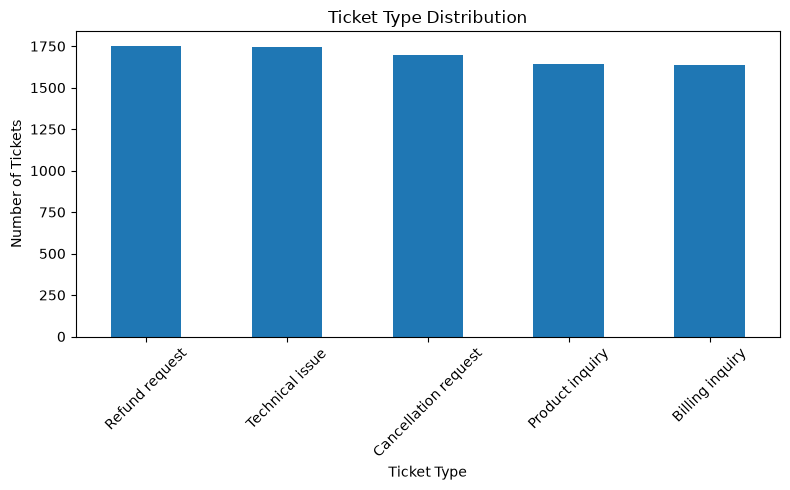

In [419]:
ticket_type_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ticket priority distribution

In [420]:
priority_counts = df["ticket_priority"].value_counts()
priority_counts

ticket_priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

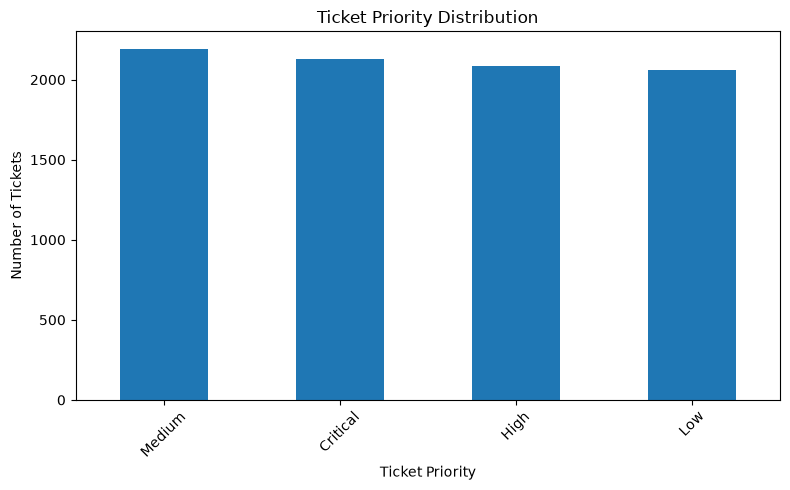

In [421]:
priority_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Priority Distribution")
plt.xlabel("Ticket Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ticket status distribution

In [422]:
status_counts = df["ticket_status"].value_counts()
status_counts

ticket_status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

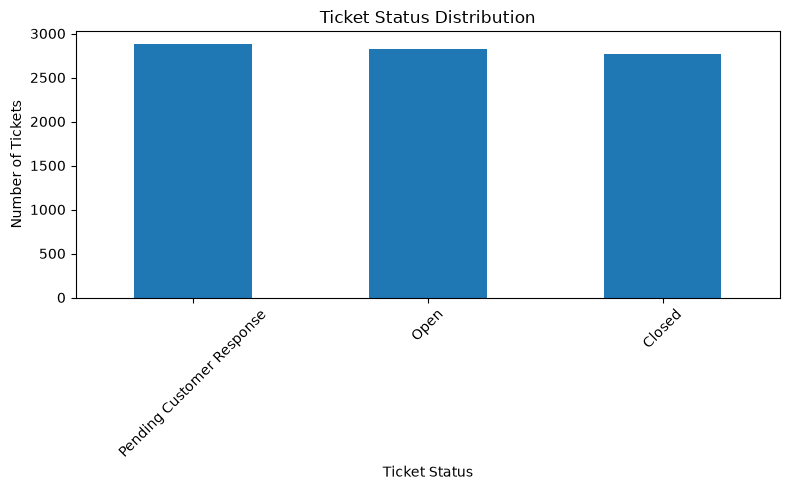

In [423]:
status_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Status Distribution")
plt.xlabel("Ticket Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ticket channel distribution

In [424]:
channel_counts = df["ticket_channel"].value_counts()
channel_counts

ticket_channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

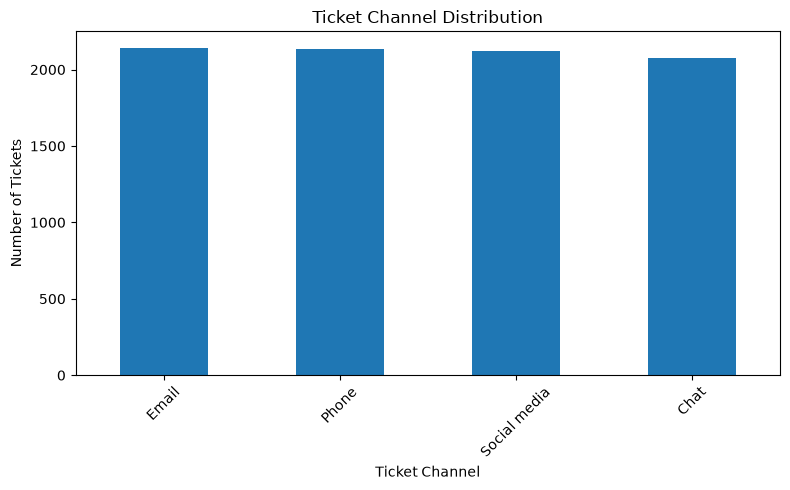

In [425]:
channel_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Channel Distribution")
plt.xlabel("Ticket Channel")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product-level ticket volume

In [426]:
product_counts = df["product_purchased"].value_counts().head(10)
product_counts

product_purchased
Canon EOS              240
GoPro Hero             228
Nest Thermostat        225
Philips Hue Lights     221
Amazon Echo            221
LG Smart TV            219
Sony Xperia            217
Roomba Robot Vacuum    216
LG OLED                213
Apple AirPods          213
Name: count, dtype: int64

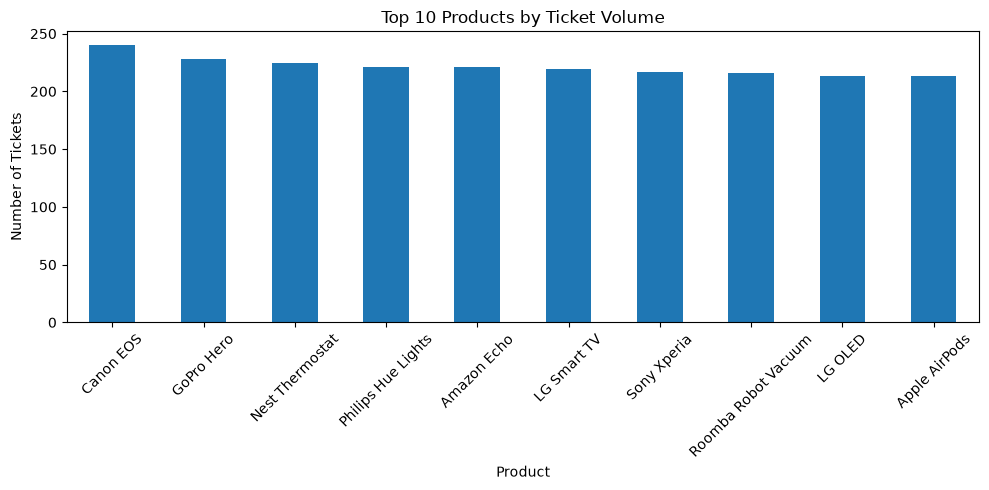

In [427]:
product_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Products by Ticket Volume")
plt.xlabel("Product")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer satisfaction analysis

In [428]:
df["customer_satisfaction_rating"].describe()

count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: customer_satisfaction_rating, dtype: float64

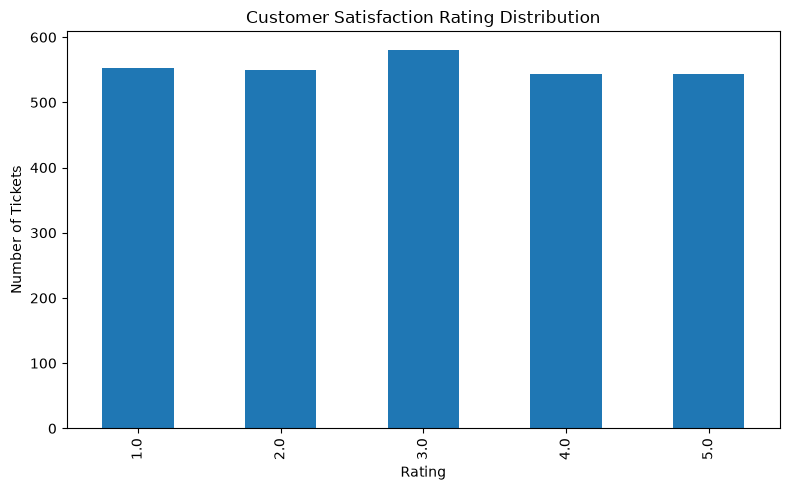

In [429]:
df["customer_satisfaction_rating"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))
plt.title("Customer Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

Average satisfaction by ticket type

In [430]:
satisfaction_by_type = (
    df.groupby("ticket_type")["customer_satisfaction_rating"]
    .mean()
    .sort_values(ascending=False)
)

satisfaction_by_type

ticket_type
Cancellation request    3.029070
Billing inquiry         3.027574
Product inquiry         3.016886
Technical issue         2.958621
Refund request          2.934564
Name: customer_satisfaction_rating, dtype: float64

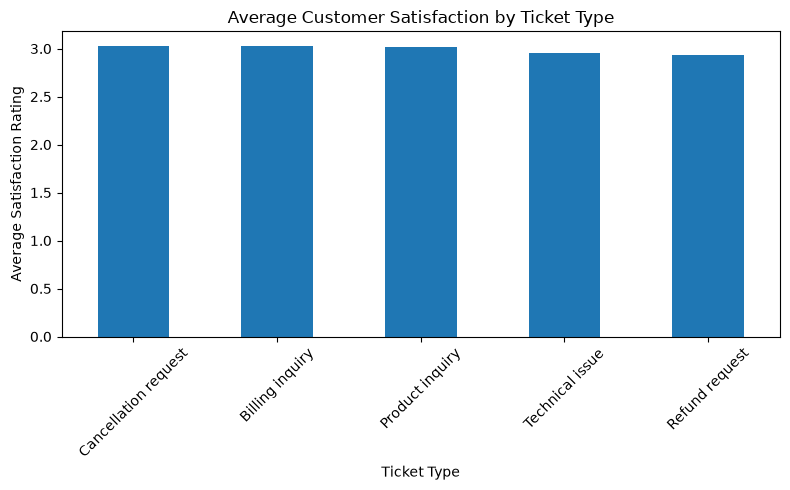

In [431]:
satisfaction_by_type.plot(kind="bar", figsize=(8, 5))
plt.title("Average Customer Satisfaction by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Satisfaction Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text length feature

This will help later when we build the ML model.

In [432]:
# Create missingness indicators before filling missing values
df["ticket_description_was_missing"] = df["ticket_description"].isnull().astype(int)
df["ticket_subject_was_missing"] = df["ticket_subject"].isnull().astype(int)
df["resolution_was_missing"] = df["resolution"].isnull().astype(int)

# Create text length features safely
df["description_length"] = df["ticket_description"].fillna("").astype(str).str.len()
df["subject_length"] = df["ticket_subject"].fillna("").astype(str).str.len()
df["resolution_length"] = df["resolution"].fillna("").astype(str).str.len()

df[[
    "description_length",
    "subject_length",
    "resolution_length",
    "ticket_description_was_missing",
    "ticket_subject_was_missing",
    "resolution_was_missing"
]].describe()

,description_length,subject_length,resolution_length,ticket_description_was_missing,ticket_subject_was_missing,resolution_was_missing
count,8469.000000,8469.000000,8469.000000,8469.0,8469.0,8469.000000
mean,289.821939,15.724879,11.704452,0.0,0.0,0.673043
std,43.593954,4.108544,17.881126,0.0,0.0,0.469129
min,151.000000,9.000000,0.000000,0.0,0.0,0.000000
25%,273.000000,13.000000,0.000000,0.0,0.0,0.000000
50%,298.000000,14.000000,0.000000,0.0,0.0,1.000000
75%,318.000000,20.000000,27.000000,0.0,0.0,1.000000
max,397.000000,24.000000,69.000000,0.0,0.0,1.000000


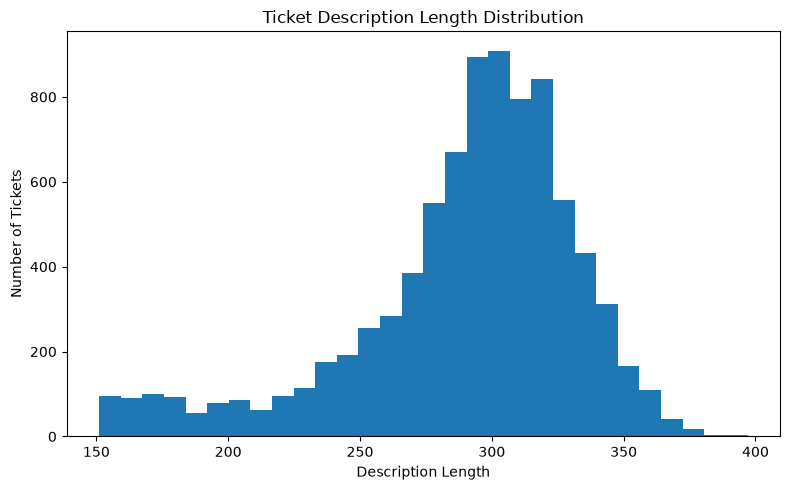

In [433]:
df["description_length"].plot(kind="hist", bins=30, figsize=(8, 5))
plt.title("Ticket Description Length Distribution")
plt.xlabel("Description Length")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

Create combined text field
For classification, we will use both subject and description.

In [434]:
df["ticket_text"] = (
    df["ticket_subject"].astype(str).fillna("") 
    + " " 
    + df["ticket_description"].astype(str).fillna("")
)

df[["ticket_subject", "ticket_description", "ticket_text"]].head()

,ticket_subject,ticket_description,ticket_text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...


Check sample ticket texts

In [435]:
for i in range(5):
    print("Ticket Type:", df.loc[i, "ticket_type"])
    print("Priority:", df.loc[i, "ticket_priority"])
    print("Text:", df.loc[i, "ticket_text"])
    print("-" * 80)

Ticket Type: Technical issue
Priority: Critical
Text: Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
--------------------------------------------------------------------------------
Ticket Type: Technical issue
Priority: Critical
Text: Peripheral compatibility I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
--------------------------------------------------------------------------------
Ticket Type: Technical issue
Priority: Low
Text: Network problem I'm facing a problem with my {product_purchased}. The {pro

Data Cleaning for Next Stage

Select useful columns

In [436]:
selected_columns = [
    "ticket_id",
    "customer_age",
    "customer_gender",
    "product_purchased",
    "date_of_purchase",
    "ticket_type",
    "ticket_subject",
    "ticket_description",
    "ticket_text",
    "ticket_status",
    "resolution",
    "ticket_priority",
    "ticket_channel",
    "first_response_time",
    "time_to_resolution",
    "customer_satisfaction_rating",
    "description_length",
    "subject_length",
    "resolution_length"
]

clean_df = df[selected_columns].copy()

clean_df.head()

,ticket_id,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_text,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,description_length,subject_length,resolution_length
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,284,13,0
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,282,24,0
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,275,15,44
3,4,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,262,14,45
4,5,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,333,9,27


Handle missing values

In [437]:
clean_df = df[selected_columns + [
    col for col in df.columns if col.endswith("_was_missing")
]].copy()

# Text fields: fill with clear placeholders because ML/RAG cannot process NaN text safely
text_columns = [
    "ticket_subject",
    "ticket_description",
    "ticket_text",
    "resolution"
]

for col in text_columns:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna(f"No {col.replace('_', ' ')} provided")

# Categorical fields: fill only if missing exists
categorical_columns = [
    "customer_gender",
    "product_purchased",
    "ticket_type",
    "ticket_status",
    "ticket_priority",
    "ticket_channel"
]

for col in categorical_columns:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Unknown")

# Numeric fields: do not assume missing satisfaction means 0 satisfaction
# Use -1 as placeholder and keep the missingness flag
numeric_columns = [
    "customer_age",
    "customer_satisfaction_rating",
    "description_length",
    "subject_length",
    "resolution_length"
]

for col in numeric_columns:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna(-1)

# Time fields: keep missingness flags and leave as placeholder text for now
time_columns = [
    "first_response_time",
    "time_to_resolution",
    "date_of_purchase"
]

for col in time_columns:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna("Not available")

clean_df.isnull().sum().sort_values(ascending=False)

ticket_id                                   0
customer_age                                0
customer_gender                             0
product_purchased                           0
date_of_purchase                            0
ticket_type                                 0
ticket_subject                              0
ticket_description                          0
ticket_text                                 0
ticket_status                               0
resolution                                  0
ticket_priority                             0
ticket_channel                              0
first_response_time                         0
time_to_resolution                          0
customer_satisfaction_rating                0
description_length                          0
subject_length                              0
resolution_length                           0
resolution_was_missing                      0
customer_satisfaction_rating_was_missing    0
first_response_time_was_missing   

## Missing Value Interpretation

Missing values were not automatically dropped because some fields may be missing for valid business reasons.

For example:
- `resolution` may be missing if a ticket is still open or pending.
- `time_to_resolution` may be missing for unresolved tickets.
- `customer_satisfaction_rating` may be missing if the customer has not rated the support experience yet.

To preserve this information, missingness indicator columns were created before imputation. These flags allow future models and dashboards to distinguish between actual values and originally missing values.

Save cleaned dataset

In [438]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Cleaned dataset saved to: {PROCESSED_DATA_PATH}")
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])


Cleaned dataset saved to: ..\data\processed\cleaned_support_tickets.csv
Rows: 8469
Columns: 25


Generating sample data for Git

In [439]:
clean_df.sample(200, random_state=42).to_csv("../data/sample/sample_support_tickets.csv", index=False)

Final summary

In [440]:
valid_satisfaction = clean_df[
    clean_df["customer_satisfaction_rating"] >= 0
]["customer_satisfaction_rating"]

summary = {
    "total_tickets": int(clean_df.shape[0]),
    "total_columns": int(clean_df.shape[1]),
    "ticket_types": int(clean_df["ticket_type"].nunique()),
    "priority_levels": int(clean_df["ticket_priority"].nunique()),
    "ticket_channels": int(clean_df["ticket_channel"].nunique()),
    "ticket_statuses": int(clean_df["ticket_status"].nunique()),
    "avg_satisfaction_rating_valid_only": round(valid_satisfaction.mean(), 2),
    "missing_satisfaction_records": int((clean_df["customer_satisfaction_rating"] == -1).sum()),
    "avg_description_length": round(clean_df["description_length"].mean(), 2)
}

summary

{'total_tickets': 8469,
 'total_columns': 25,
 'ticket_types': 5,
 'priority_levels': 4,
 'ticket_channels': 4,
 'ticket_statuses': 3,
 'avg_satisfaction_rating_valid_only': np.float64(2.99),
 'missing_satisfaction_records': 5700,
 'avg_description_length': np.float64(289.82)}

## Summary of Findings

The dataset contains customer support tickets with useful fields for classification, priority analysis, SQL reporting, dashboarding, and support automation.

Key observations:
- The dataset includes ticket type, priority, status, channel, product, resolution, response-time fields, and customer satisfaction rating.
- Ticket type can be used as the main classification target.
- Ticket priority can be used later for a second prediction model.
- Ticket text was created by combining ticket subject and ticket description.
- Missing values were not blindly dropped. Missingness was reviewed to understand whether values may be absent for valid business reasons, such as unresolved tickets not having a final resolution.
- Missingness indicator columns were created before filling missing values so that originally missing information is preserved for future analysis, modeling, and dashboards.
- Text fields were safely filled with clear placeholders, categorical fields with `Unknown`, numeric fields with `-1`, and time fields with `Not available`.
- The cleaned dataset has been saved to `data/processed/cleaned_support_tickets.csv`.

Next step:
Build a machine learning model to classify support tickets by ticket type.